In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [2]:
import pycaret
print(pycaret.__version__)

3.3.2


In [13]:
!pip install pycaret -q
print('PyCaret installed. RESTART THE RUNTIME NOW: Runtime → Restart runtime')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 102.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 127.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 135.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# ── Paste the path printed in Step 1b here ────────────────────────────────────
DATA_PATH = '/content/drive/MyDrive/fpl_thesis/data/processed/featured_training_set.csv'

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Loaded: 52608 rows, 70 columns


,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,...,pts_per_million,price_change,opp_avg_goals_scored,opp_avg_goals_conceded,played_60_plus,blanked,games_played,gi_rate,rolling_yellows_3,red_card_flag
0,Aaron Hickey,DEF,Brentford,2.0,0,0,7,0,10.8,104,...,0.000000,0.0,NaN,NaN,1,1,1,0.0,NaN,0
1,Aaron Hickey,DEF,Brentford,2.5,0,0,15,1,1.5,104,...,1.111111,0.0,2.0,20.0,1,0,2,0.0,1.000000,0
2,Aaron Hickey,DEF,Brentford,2.3,0,0,13,0,3.8,104,...,0.444444,0.0,2.5,10.0,1,0,3,0.0,1.000000,0
3,Aaron Hickey,DEF,Brentford,2.0,0,0,19,0,1.2,104,...,0.222222,0.0,2.0,10.0,1,1,4,0.0,0.666667,0
4,Aaron Hickey,DEF,Brentford,0.8,0,0,6,0,1.3,104,...,0.222222,0.0,2.0,12.0,1,1,5,0.0,0.333333,0


In [4]:
# ── Create the TARGET: next GW points for each player ─────────────────────────
# Shift total_points by -1 within each player+season group.
# Given THIS gameweek's features → predict NEXT gameweek's points.
df = df.sort_values(['name', 'season', 'GW'])
df['target'] = df.groupby(['name', 'season'])['total_points'].shift(-1)

# Drop the last GW of each season (no next GW to predict)
df = df.dropna(subset=['target']).reset_index(drop=True)
print(f'After creating target: {df.shape[0]} rows')

After creating target: 50932 rows


In [5]:
# ── Drop identifier and leakage columns ───────────────────────────────────────
DROP_COLS = [
    'name', 'team', 'season', 'GW', 'kickoff_time',
    'total_points',  # raw target — already encoded as 'target'
    'element',       # player ID
    'fixture',       # fixture ID
    'modified',      # metadata
]
DROP_COLS = [c for c in DROP_COLS if c in df.columns]

# ── Encode categoricals ────────────────────────────────────────────────────────
df['position'] = df['position'].astype('category').cat.codes  # GK=0 DEF=1 MID=2 FWD=3
df['was_home'] = df['was_home'].astype(int)

# ── Build modelling dataframe ──────────────────────────────────────────────────
model_df = df.drop(columns=DROP_COLS)

# Drop any remaining non-numeric columns
non_numeric = model_df.select_dtypes(exclude=[np.number, 'bool']).columns.tolist()
if non_numeric:
    print(f'Dropping non-numeric columns: {non_numeric}')
    model_df = model_df.drop(columns=non_numeric)

print(f'Modelling dataframe: {model_df.shape}')
print(f'Target stats:\n{model_df["target"].describe()}')

Modelling dataframe: (50932, 62)
Target stats:
count    50932.000000
mean         1.358439
std          2.543321
min         -4.000000
25%          0.000000
50%          0.000000
75%          2.000000
max         26.000000
Name: target, dtype: float64


In [6]:
# ── Walk-Forward Train / Test Split ───────────────────────────────────────────
model_df['season'] = df['season'].values
model_df['GW']     = df['GW'].values

train_mask = (
    model_df['season'].isin([2324, 2425]) |
    ((model_df['season'] == 2526) & (model_df['GW'] <= 25))
)
test_mask = (model_df['season'] == 2526) & (model_df['GW'] >= 26)

train_df  = model_df[train_mask].drop(columns=['season', 'GW']).reset_index(drop=True)
test_df   = model_df[test_mask].drop(columns=['season', 'GW']).reset_index(drop=True)

# Save player metadata for the final predictions output
test_meta = df[test_mask][['name', 'team', 'position', 'GW', 'season', 'value']].reset_index(drop=True)

print(f'Train: {train_df.shape} | Test: {test_df.shape}')

Train: (48399, 62) | Test: (2533, 62)


  Pycaret

In [ ]:
from pycaret.regression import *

pc_setup = setup(
    data            = train_df,
    target          = 'target',
    session_id      = 42,
    fold            = 5,
    verbose         = True,
    use_gpu         = True,
    remove_outliers = True,
    normalize       = True,
)
print('PyCaret setup complete.')

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that mee

,Description,Value
0,Session id,42
1,Target,target
2,Target type,Regression
3,Original data shape,"(48399, 62)"
4,Transformed data shape,"(46705, 62)"
5,Transformed train set shape,"(32185, 62)"
6,Transformed test set shape,"(14520, 62)"
7,Numeric features,61
8,Rows with missing values,100.0%
9,Preprocess,True


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that mee

In [ ]:
# Benchmark all models — sorted by MAE
# n_select=3 keeps the top 3 for the ensemble prediction interval later
best_models = compare_models(
    sort     = 'MAE',
    n_select = 3,
    exclude  = ['ransac']
)
print('\nTop 3 models selected.')

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
huber,Huber Regressor,1.0214,5.1844,2.2766,0.1946,0.5319,0.6020,1.9340
lightgbm,Light Gradient Boosting Machine,1.1599,4.5992,2.1443,0.2854,0.5419,0.7862,2.8560
catboost,CatBoost Regressor,1.1644,4.5966,2.1436,0.2859,0.5423,0.7867,12.4560
gbr,Gradient Boosting Regressor,1.1738,4.6174,2.1487,0.2823,0.5444,0.7997,10.8200
lr,Linear Regression,1.1866,4.5410,2.1307,0.2945,0.5459,0.7889,0.7440
ridge,Ridge Regression,1.1868,4.5403,2.1305,0.2946,0.5459,0.7894,0.6800
br,Bayesian Ridge,1.1876,4.5403,2.1305,0.2946,0.5463,0.7859,0.7880
omp,Orthogonal Matching Pursuit,1.1963,4.5745,2.1386,0.2892,0.5512,0.7767,0.8220
knn,K Neighbors Regressor,1.2211,5.2975,2.3014,0.1767,0.5935,0.8738,0.6560
et,Extra Trees Regressor,1.2324,4.7568,2.1809,0.2605,0.5712,0.8975,16.4740


Processing:   0%|          | 0/83 [00:00<?, ?it/s]

[2026-04-05 12:37:17.516] [CUML] [info] Unused keyword parameter: n_jobs during cuML estimator initialization



Top 3 models selected.


In [ ]:
import os
import pickle

os.makedirs('/content/drive/MyDrive/fpl_thesis/models', exist_ok=True)

with open('/content/drive/MyDrive/fpl_thesis/models/best_models.pkl', 'wb') as f:
    pickle.dump(best_models, f)

print('Models saved to Drive.')

Models saved to Drive.


In [ ]:
# Tune the best model
tuned_model = tune_model(best_models[0], optimize='MAE', n_iter=20)
print(f'Best model after tuning: {type(tuned_model).__name__}')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.0120,5.3782,2.3191,0.1762,0.5407,0.5938
1,0.9953,5.0712,2.2519,0.1958,0.5296,0.6019
2,1.0376,5.3259,2.3078,0.1837,0.5440,0.6120
3,1.0379,5.4411,2.3326,0.1859,0.5430,0.6110
4,1.0066,4.9747,2.2304,0.1897,0.5386,0.6209
Mean,1.0179,5.2382,2.2884,0.1863,0.5392,0.6079
Std,0.0171,0.1821,0.0399,0.0065,0.0051,0.0093


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Best model after tuning: HuberRegressor


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

final_pycaret_model = finalize_model(tuned_model)
pycaret_preds = predict_model(final_pycaret_model, data=test_df)
mae_pc = mean_absolute_error(pycaret_preds['target'], pycaret_preds['prediction_label'])
r2_pc  = r2_score(pycaret_preds['target'], pycaret_preds['prediction_label'])

print(f'PyCaret Test MAE : {mae_pc:.4f}')
print(f'PyCaret Test R²  : {r2_pc:.4f}')

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Huber Regressor,0.7969,3.9881,1.9970,0.2388,0.4774,0.6060


PyCaret Test MAE : 0.7969
PyCaret Test R²  : 0.2388


In [ ]:
save_model(final_pycaret_model, '/content/drive/MyDrive/fpl_thesis/models/pycaret_best_model')
print('PyCaret model saved.')

Transformation Pipeline and Model Successfully Saved
PyCaret model saved.


In [ ]:
import json
results = {
    'model': 'HuberRegressor',
    'cv_mae': 1.0179,
    'cv_r2': 0.1863,
    'test_mae': 0.7969,
    'test_r2': 0.2388
}
with open('/content/drive/MyDrive/fpl_thesis/models/pycaret_results.json', 'w') as f:
    json.dump(results, f)
print('Results saved.')

Results saved.


In [ ]:
# Naive baseline: predict each player's mean points
naive_pred = test_df['target'].mean()
naive_mae = mean_absolute_error(test_df['target'], [naive_pred] * len(test_df))
print(f'Naive baseline MAE: {naive_mae:.4f}')

Naive baseline MAE: 1.4483


AUTOKERAS

In [3]:
!pip install autokeras -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.7/124.7 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 20.3 MB/s eta 0:00:00


In [11]:
import autokeras as ak
import tensorflow as tf

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

X_train = train_df.drop(columns=['target']).values.astype(np.float32)
y_train = train_df['target'].values.astype(np.float32)
X_test  = test_df.drop(columns=['target']).values.astype(np.float32)
y_test  = test_df['target'].values.astype(np.float32)

TensorFlow : 2.18.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [19]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed  = imputer.transform(X_test)

print(f'NaNs in X_train after imputation: {np.isnan(X_train_imputed).sum()}')
print(f'NaNs in X_test after imputation: {np.isnan(X_test_imputed).sum()}')

NaNs in X_train after imputation: 0
NaNs in X_test after imputation: 0


In [11]:
ak_model = ak.StructuredDataRegressor(
    max_trials  = 10,
    overwrite   = True,
    seed        = 42,
    objective   = 'val_loss',
    directory   = '/content/drive/MyDrive/fpl_thesis/models/autokeras_trials'
)

ak_model.fit(
    X_train, y_train,
    epochs           = 50,
    validation_split = 0.1,
    verbose          = 1
)
print('AutoKeras training complete.')

Trial 10 Complete [00h 01m 33s]
val_loss: 3.455624580383301

Best val_loss So Far: 3.423128604888916
Total elapsed time: 00h 12m 43s
Epoch 1/50
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 5.5436 - mean_squared_error: 5.5436
Epoch 2/50
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 4.6522 - mean_squared_error: 4.6522
Epoch 3/50
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 4.7196 - mean_squared_error: 4.7196
Epoch 4/50
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 4.7821 - mean_squared_error: 4.7821
Epoch 5/50
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 4.6578 - mean_squared_error: 4.6578
Epoch 6/50
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 4.6086 - mean_squared_error: 4.6086
Epoch 7/50
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 4.6600 - mean_squared_error: 4.6600
Epoch 8/50
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 4.4791 - mean_squared_error: 4.4791
Epoch 9/50
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 4.6220 - mean_squared

In [10]:
import autokeras as ak
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

# Reload AutoKeras model from saved trials
ak_model = ak.StructuredDataRegressor(
    max_trials  = 10,
    overwrite   = False,  # important — don't overwrite, load existing trials
    seed        = 42,
    objective   = 'val_loss',
    directory   = '/content/drive/MyDrive/fpl_thesis/models/autokeras_trials'
)

# Refit on training data to restore the model state
ak_model.fit(
    X_train, y_train,
    epochs           = 50,
    validation_split = 0.1,
    verbose          = 1
)

print('Model restored.')

Reloading Tuner from /content/drive/MyDrive/fpl_thesis/models/autokeras_trials/structured_data_regressor/tuner0.json
Epoch 1/50
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 5.2956 - mean_squared_error: 5.2956
Epoch 2/50
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 4.8379 - mean_squared_error: 4.8379
Epoch 3/50
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 4.7667 - mean_squared_error: 4.7667
Epoch 4/50
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 4.7758 - mean_squared_error: 4.7758
Epoch 5/50
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 4.6322 - mean_squared_error: 4.6322
Epoch 6/50
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 4.6442 - mean_squared_error: 4.6442
Epoch 7/50
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 4.6301 - mean_squared_error: 4.6301
Epoch 8/50
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 4.5040 - mean_squared_error: 4.5040
Epoch 9/50
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 4.5795 - mean_squared_error: 4.5795


In [11]:
# Evaluate
ak_preds_raw = ak_model.predict(X_test).flatten()
mae_ak = mean_absolute_error(y_test, ak_preds_raw)
r2_ak  = r2_score(y_test, ak_preds_raw)

print(f'AutoKeras Test MAE : {mae_ak:.4f}')
print(f'AutoKeras Test R²  : {r2_ak:.4f}')

# Save immediately
best_ak_model = ak_model.export_model()
best_ak_model.save('/content/drive/MyDrive/fpl_thesis/models/autokeras_best_model.keras')

import json
ak_results = {
    'model': 'AutoKeras Neural Network',
    'test_mae': round(mae_ak, 4),
    'test_r2': round(r2_ak, 4)
}
with open('/content/drive/MyDrive/fpl_thesis/models/autokeras_results.json', 'w') as f:
    json.dump(ak_results, f)

print('AutoKeras model and results saved to Drive.')

80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
AutoKeras Test MAE : 0.9683
AutoKeras Test R²  : 0.3346
AutoKeras model and results saved to Drive.


===== Model Comparison =====
                     Model    MAE     R²
  PyCaret (HuberRegressor) 0.7969 0.2388
AutoKeras (Neural Network) 0.9683 0.3346
            Naive Baseline 1.4483    NaN


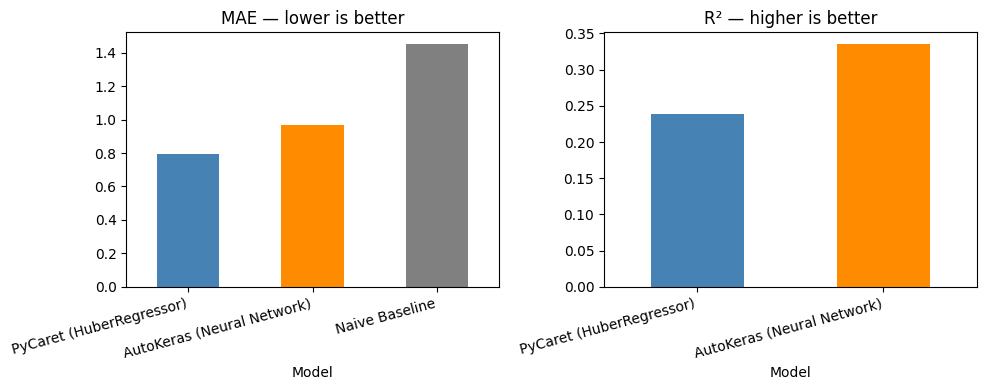


Winner by MAE: PyCaret (HuberRegressor)


In [12]:
import matplotlib.pyplot as plt
import pandas as pd

comparison = pd.DataFrame({
    'Model' : ['PyCaret (HuberRegressor)', 'AutoKeras (Neural Network)', 'Naive Baseline'],
    'MAE'   : [0.7969, 0.9683, 1.4483],
    'R²'    : [0.2388, 0.3346, None],
})

print('===== Model Comparison =====')
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['steelblue', 'darkorange', 'gray']

comparison.plot(kind='bar', x='Model', y='MAE', ax=axes[0], color=colors, legend=False)
axes[0].set_title('MAE — lower is better')
axes[0].set_xticklabels(comparison['Model'], rotation=15, ha='right')

comparison.dropna().plot(kind='bar', x='Model', y='R²', ax=axes[1], color=colors[:2], legend=False)
axes[1].set_title('R² — higher is better')
axes[1].set_xticklabels(comparison.dropna()['Model'], rotation=15, ha='right')

plt.tight_layout()

import os
os.makedirs('/content/drive/MyDrive/fpl_thesis/outputs', exist_ok=True)
plt.savefig('/content/drive/MyDrive/fpl_thesis/outputs/model_comparison.png', dpi=150)
plt.show()

winner = 'PyCaret (HuberRegressor)' if 0.7969 <= 0.9683 else 'AutoKeras'
print(f'\nWinner by MAE: {winner}')

In [7]:
from pycaret.regression import load_model, predict_model

final_pycaret_model = load_model('/content/drive/MyDrive/fpl_thesis/models/pycaret_best_model')
print('PyCaret model loaded.')

Transformation Pipeline and Model Successfully Loaded
PyCaret model loaded.


In [8]:
pycaret_preds = predict_model(final_pycaret_model, data=test_df)
pycaret_preds.to_csv('/content/drive/MyDrive/fpl_thesis/models/pycaret_preds.csv', index=False)
print('PyCaret predictions saved.')

PyCaret predictions saved.


In [12]:
import autokeras as ak
import tensorflow as tf
import numpy as np

# Check AutoKeras is available
print(f'AutoKeras version: {autokeras.__version__}')

# Reload the saved AutoKeras model
best_ak_model = tf.keras.models.load_model(
    '/content/drive/MyDrive/fpl_thesis/models/autokeras_best_model.keras',
    custom_objects=ak.CUSTOM_OBJECTS
)

# Generate predictions
ak_preds_raw = best_ak_model.predict(X_test).flatten()
print(f'AutoKeras predictions generated: {len(ak_preds_raw)} rows')

AutoKeras version: 3.0.0
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
AutoKeras predictions generated: 2533 rows


In [13]:
import pandas as pd

# Load saved PyCaret predictions
pc_preds_df = pd.read_csv('/content/drive/MyDrive/fpl_thesis/models/pycaret_preds.csv')
pc_preds_raw = pc_preds_df['prediction_label'].values

print(f'PyCaret predictions loaded: {len(pc_preds_raw)} rows')
print(f'AutoKeras predictions: {len(ak_preds_raw)} rows')

PyCaret predictions loaded: 2533 rows
AutoKeras predictions: 2533 rows


INTERVALS

In [21]:
# Combine PyCaret and AutoKeras predictions
all_preds = np.array([pc_preds_raw, ak_preds_raw])

mid  = all_preds.mean(axis=0)
std  = all_preds.std(axis=0)
low  = np.clip(mid - std, 0, None)
high = mid + std

# Confidence bucketing
interval_width = high - low
q33, q66 = np.percentile(interval_width, [33, 66])

def get_confidence(w):
    if w <= q33:   return 'High'
    elif w <= q66: return 'Medium'
    else:          return 'Low'

confidence = [get_confidence(w) for w in interval_width]

# Build final predictions dataframe
predictions_df = test_meta.copy().reset_index(drop=True)
predictions_df['predicted_pts_mid']  = np.round(mid,  2)
predictions_df['predicted_pts_low']  = np.round(low,  2)
predictions_df['predicted_pts_high'] = np.round(high, 2)
predictions_df['confidence']         = confidence
predictions_df['actual_pts']         = y_test

print(predictions_df[[
    'name', 'team', 'position', 'GW', 'value',
    'predicted_pts_low', 'predicted_pts_mid',
    'predicted_pts_high', 'confidence', 'actual_pts'
]].head(10))

OUT_PATH = '/content/drive/MyDrive/fpl_thesis/data/processed/predictions.csv'
predictions_df.to_csv(OUT_PATH, index=False)
print(f'\nSaved to {OUT_PATH}')
print(f'Shape: {predictions_df.shape}')

                name       team  position  GW  value  predicted_pts_low  \
0       Aaron Hickey  Brentford         0  26    4.0               0.06   
1       Aaron Hickey  Brentford         0  27    4.0               0.73   
2       Aaron Hickey  Brentford         0  28    4.0               0.00   
3     Aaron Ramsdale  Newcastle         2  26    4.8               0.00   
4     Aaron Ramsdale  Newcastle         2  27    4.8               0.00   
5     Aaron Ramsdale  Newcastle         2  28    4.8               0.00   
6       Aaron Ramsey    Burnley         3  26    4.4               0.00   
7       Aaron Ramsey    Burnley         3  27    4.4               0.00   
8       Aaron Ramsey    Burnley         3  28    4.4               0.00   
9  Aaron Wan-Bissaka   West Ham         0  26    4.1               1.99   

   predicted_pts_mid  predicted_pts_high confidence  actual_pts  
0               0.19                0.32       High         1.0  
1               0.74                0.75  

In [16]:
predictions_df = test_meta.copy().reset_index(drop=True)
predictions_df['predicted_pts_mid']  = np.round(mid,  2)
predictions_df['predicted_pts_low']  = np.round(low,  2)
predictions_df['predicted_pts_high'] = np.round(high, 2)
predictions_df['confidence']         = confidence
predictions_df['actual_pts']         = y_test

print(predictions_df[[
    'name', 'team', 'position', 'GW', 'value',
    'predicted_pts_low', 'predicted_pts_mid',
    'predicted_pts_high', 'confidence', 'actual_pts'
]].head(10))

OUT_PATH = '/content/drive/MyDrive/fpl_thesis/data/processed/predictions.csv'
predictions_df.to_csv(OUT_PATH, index=False)
print(f'\nSaved to {OUT_PATH}')
print(f'Shape: {predictions_df.shape}')

                name       team  position  GW  value  predicted_pts_low  \
0       Aaron Hickey  Brentford         0  26    4.0                NaN   
1       Aaron Hickey  Brentford         0  27    4.0                NaN   
2       Aaron Hickey  Brentford         0  28    4.0                NaN   
3     Aaron Ramsdale  Newcastle         2  26    4.8                NaN   
4     Aaron Ramsdale  Newcastle         2  27    4.8                NaN   
5     Aaron Ramsdale  Newcastle         2  28    4.8                NaN   
6       Aaron Ramsey    Burnley         3  26    4.4                NaN   
7       Aaron Ramsey    Burnley         3  27    4.4                NaN   
8       Aaron Ramsey    Burnley         3  28    4.4                NaN   
9  Aaron Wan-Bissaka   West Ham         0  26    4.1                NaN   

   predicted_pts_mid  predicted_pts_high confidence  actual_pts  
0                NaN                 NaN        Low         1.0  
1                NaN                 NaN  

In [20]:
ak_preds_raw = best_ak_model.predict(X_test_imputed).flatten()
print(f'Sample: {ak_preds_raw[:5]}')

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Sample: [0.31936327 0.7345753  0.31233197 0.47336656 0.61220515]


In [22]:
premium = ['Salah', 'Haaland', 'Palmer', 'Mbeumo']
for player in premium:
    player_preds = predictions_df[predictions_df['name'].str.contains(player)]
    if len(player_preds) > 0:
        print(player_preds[['name', 'GW', 'predicted_pts_mid', 'actual_pts']].to_string())
        print()

               name  GW  predicted_pts_mid  actual_pts
1771  Mohamed Salah  26               2.10         3.0
1772  Mohamed Salah  27               1.57         2.0
1773  Mohamed Salah  28               2.12         9.0

               name  GW  predicted_pts_mid  actual_pts
677  Erling Haaland  26               1.87         6.0
678  Erling Haaland  27               2.85         0.0
679  Erling Haaland  28               0.64         2.0

            name  GW  predicted_pts_mid  actual_pts
438  Cole Palmer  26               2.45         3.0
439  Cole Palmer  27               2.59         1.0
440  Cole Palmer  28               2.36         9.0

             name  GW  predicted_pts_mid  actual_pts
325  Bryan Mbeumo  26               2.13         6.0
326  Bryan Mbeumo  27               1.54         2.0
327  Bryan Mbeumo  28               2.41         1.0



In [23]:
print(predictions_df['GW'].unique())
print(predictions_df['GW'].value_counts().sort_index())

[26 27 28]
GW
26    896
27    818
28    819
Name: count, dtype: int64


Linear Programming

In [24]:
!pip install pulp -q

import pandas as pd
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 64.7 MB/s eta 0:00:00
Optimising for GW28 — 819 players available


In [34]:
from pulp import *
import pandas as pd
import numpy as np

# ── Load and Average Predictions Across All GWs ───────────────────────────────
df_all = pd.read_csv('/content/drive/MyDrive/fpl_thesis/data/processed/predictions.csv')

df = df_all.groupby(['name', 'team', 'position']).agg(
    value              = ('value', 'last'),
    predicted_pts_mid  = ('predicted_pts_mid', 'mean'),
    predicted_pts_low  = ('predicted_pts_low', 'mean'),
    predicted_pts_high = ('predicted_pts_high', 'mean'),
    confidence         = ('confidence', 'last'),
).reset_index()

print(f'Players after averaging: {len(df)}')

# ── Fix Position Mapping ───────────────────────────────────────────────────────
position_map = {0: 'DEF', 1: 'FWD', 2: 'GK', 3: 'MID'}
df['pos'] = df['position'].map(position_map)

# ── Scale Predictions ──────────────────────────────────────────────────────────
df['predicted_pts_scaled'] = (
    df['predicted_pts_mid'] * 0.4 +
    (df['value'] / df['value'].max()) * df['predicted_pts_mid'].max() * 0.6
)

# Check premium players
print('\nPremium players after averaging and scaling:')
premium = ['Salah', 'Haaland', 'Palmer', 'Mbeumo', 'Semenyo', 'van Dijk']
for player in premium:
    result = df[df['name'].str.contains(player)]
    if len(result) > 0:
        print(result[['name', 'pos', 'value', 'predicted_pts_mid', 'predicted_pts_scaled']].to_string())
        print()

# ── Decision Variables ─────────────────────────────────────────────────────────
players = list(df.index)

starter = LpVariable.dicts('starter', players, cat='Binary')
benched = LpVariable.dicts('benched', players, cat='Binary')
captain = LpVariable.dicts('captain', players, cat='Binary')

# ── Problem Definition ─────────────────────────────────────────────────────────
prob = LpProblem('FPL_Squad_Optimisation', LpMaximize)

prob += (
    lpSum(starter[i] * df.loc[i, 'predicted_pts_scaled'] for i in players) +
    lpSum(captain[i] * df.loc[i, 'predicted_pts_scaled'] for i in players)
)

# ── Constraints ────────────────────────────────────────────────────────────────
prob += lpSum(starter[i] for i in players) == 11
prob += lpSum(benched[i] for i in players) == 4

for i in players:
    prob += starter[i] + benched[i] <= 1

for i in players:
    prob += captain[i] <= starter[i]
prob += lpSum(captain[i] for i in players) == 1

prob += lpSum(
    (starter[i] + benched[i]) * df.loc[i, 'value'] for i in players
) <= 100.0

gk_idx  = [i for i in players if df.loc[i, 'pos'] == 'GK']
def_idx = [i for i in players if df.loc[i, 'pos'] == 'DEF']
mid_idx = [i for i in players if df.loc[i, 'pos'] == 'MID']
fwd_idx = [i for i in players if df.loc[i, 'pos'] == 'FWD']

prob += lpSum(starter[i] + benched[i] for i in gk_idx)  == 2
prob += lpSum(starter[i] + benched[i] for i in def_idx) == 5
prob += lpSum(starter[i] + benched[i] for i in mid_idx) == 5
prob += lpSum(starter[i] + benched[i] for i in fwd_idx) == 3

prob += lpSum(starter[i] for i in gk_idx)  == 1
prob += lpSum(starter[i] for i in def_idx) >= 3
prob += lpSum(starter[i] for i in mid_idx) >= 2
prob += lpSum(starter[i] for i in fwd_idx) >= 1

for club in df['team'].unique():
    club_idx = [i for i in players if df.loc[i, 'team'] == club]
    prob += lpSum(starter[i] + benched[i] for i in club_idx) <= 3

# ── Solve ──────────────────────────────────────────────────────────────────────
solver = PULP_CBC_CMD(msg=0)
prob.solve(solver)
print(f'\nStatus: {LpStatus[prob.status]}')

# ── Extract Results ────────────────────────────────────────────────────────────
starter_ids = [i for i in players if starter[i].value() == 1]
benched_ids = [i for i in players if benched[i].value() == 1]
captain_id  = [i for i in players if captain[i].value() == 1][0]

starting_11 = df.loc[starter_ids].copy()
bench_4     = df.loc[benched_ids].copy()

starting_11['role'] = 'Starter'
starting_11.loc[captain_id, 'role'] = 'Captain'
bench_4['role'] = 'Bench'

squad = pd.concat([starting_11, bench_4])

# ── Display ────────────────────────────────────────────────────────────────────
print(f'\n{"="*60}')
print(f'OPTIMAL FPL SQUAD')
print(f'{"="*60}')

for pos in ['GK', 'DEF', 'MID', 'FWD']:
    pos_players = starting_11[starting_11['pos'] == pos].sort_values(
        'predicted_pts_scaled', ascending=False
    )
    for _, row in pos_players.iterrows():
        role = '(C)' if row['role'] == 'Captain' else '   '
        print(f"{pos} {role} {row['name']:<25} £{row['value']}m   "
              f"Pred: {row['predicted_pts_mid']:.2f} pts   "
              f"[{row['predicted_pts_low']:.2f} – {row['predicted_pts_high']:.2f}]   "
              f"Conf: {row['confidence']}")

print(f'\n--- BENCH ---')
for _, row in bench_4.sort_values('pos').iterrows():
    print(f"{row['pos']}     {row['name']:<25} £{row['value']}m   "
          f"Pred: {row['predicted_pts_mid']:.2f} pts")

total_cost = squad['value'].sum()
total_pred = (
    starting_11['predicted_pts_scaled'].sum() +
    starting_11.loc[captain_id, 'predicted_pts_scaled']
)

print(f'\nTotal Cost     : £{total_cost:.1f}m / £100.0m')
print(f'Predicted Points (scaled, with captain): {total_pred:.2f}')
print(f'Captain        : {df.loc[captain_id, "name"]}')
print(f'{"="*60}')

# ── Save ───────────────────────────────────────────────────────────────────────
import os
os.makedirs('/content/drive/MyDrive/fpl_thesis/data/processed', exist_ok=True)
squad.to_csv('/content/drive/MyDrive/fpl_thesis/data/processed/optimal_squad.csv', index=False)
print(f'\nOptimal squad saved to Drive.')

Players after averaging: 819

Premium players after averaging and scaling:
              name  pos  value  predicted_pts_mid  predicted_pts_scaled
571  Mohamed Salah  MID   14.0               1.93              2.455784

               name  pos  value  predicted_pts_mid  predicted_pts_scaled
219  Erling Haaland  FWD   14.8           1.786667              2.494667

            name  pos  value  predicted_pts_mid  predicted_pts_scaled
142  Cole Palmer  MID   10.6           2.466667              2.261532

             name  pos  value  predicted_pts_mid  predicted_pts_scaled
105  Bryan Mbeumo  MID    8.7           2.026667              1.857018

               name  pos  value  predicted_pts_mid  predicted_pts_scaled
54  Antoine Semenyo  MID    8.1           2.666667              2.040856

                name  pos  value  predicted_pts_mid  predicted_pts_scaled
775  Virgil van Dijk  DEF    6.0               2.84              1.857622


Status: Optimal

OPTIMAL FPL SQUAD
GK     Jordan Pic

In [30]:
print(f'Total cost: £{squad["value"].sum():.1f}m')
print(f'Remaining budget: £{100 - squad["value"].sum():.1f}m')
print(f'\nMost expensive players available:')
print(df.nlargest(10, 'predicted_pts_mid')[['name', 'pos', 'value', 'predicted_pts_mid']])

Total cost: £86.7m
Remaining budget: £13.3m

Most expensive players available:
                                 name  pos  value  predicted_pts_mid
775                   Virgil van Dijk  DEF    6.0               3.84
299  Igor Thiago Nascimento Rodrigues  FWD    7.1               3.19
575                     Morgan Rogers  MID    7.7               2.77
148             Crysencio Summerville  MID    5.7               2.74
54                    Antoine Semenyo  MID    8.1               2.68
26                         Alex Scott  MID    5.0               2.51
569                      Mitoma Kaoru  MID    6.1               2.50
186             Dominic Calvert-Lewin  FWD    5.8               2.47
203                   Elliot Anderson  MID    5.4               2.45
511               Marcos Senesi Barón  DEF    4.9               2.45


In [33]:
# Stronger scaling — 40% model, 60% price signal
df['predicted_pts_scaled'] = (
    df['predicted_pts_mid'] * 0.4 +
    (df['value'] / df['value'].max()) * df['predicted_pts_mid'].max() * 0.6
)

# Check again
premium = ['Salah', 'Haaland', 'Palmer', 'Mbeumo', 'Semenyo', 'van Dijk']
for player in premium:
    result = df[df['name'].str.contains(player)]
    if len(result) > 0:
        print(result[['name', 'pos', 'value', 'predicted_pts_mid', 'predicted_pts_scaled']].to_string())
        print()

              name  pos  value  predicted_pts_mid  predicted_pts_scaled
571  Mohamed Salah  MID   14.0               2.12              3.027459

               name  pos  value  predicted_pts_mid  predicted_pts_scaled
219  Erling Haaland  FWD   14.8               0.64                  2.56

            name  pos  value  predicted_pts_mid  predicted_pts_scaled
142  Cole Palmer  MID   10.6               2.36              2.594162

             name  pos  value  predicted_pts_mid  predicted_pts_scaled
105  Bryan Mbeumo  MID    8.7               2.41              2.318378

               name  pos  value  predicted_pts_mid  predicted_pts_scaled
54  Antoine Semenyo  MID    8.1               2.68              2.332973

                name  pos  value  predicted_pts_mid  predicted_pts_scaled
775  Virgil van Dijk  DEF    6.0               3.84              2.470054

